# Dataset

### Context

This dataset is from 157 Finnish listed companies 2024 CEO Reviews. The data is published in the same github folder as this jupyter notebook file. The CDP Columns have been manually coded by the author after reading through all the CEO reviews, and the sentiment columns come from a sentiment analysis Python script that can also be found from the same github folder. Sectors and segments are from [Nasdaq](https://www.nasdaq.com/european-market-activity/shares). Company names are from [Nordnet](https://www.nordnet.fi/osakkeet/kurssit?exchangeCountry=FI). <br><br> The findings are not discussed here, for more information you can find the master's thesis here (link provided later after it gets uploaded to utupub).

# Importing Libraries and Data

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import scikit_posthocs as sp
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

dataset = pd.read_excel('final_data.xlsx')
dataset

,"Company name (Nordnet, 2025)",CDP 1,CDP 2,CDP 3,CDP 4,CDP 5,CDP 6,CDP 7,CDP 8,CDP Total,Negative,Positive,Uncertainty,Litigious,Strong_Modal,Weak_Modal,Constraining,Word_Count,Segment,Sector
0,Admicom Oyj,1,0,0,1,0,0,0,1,3,0.005300,0.037102,0.003534,0.001767,0.012367,0.000000,0.001767,566,First North,Technology
1,Administer Oyj,0,1,1,1,0,0,0,1,4,0.009472,0.046008,0.010825,0.000000,0.012179,0.002706,0.002706,739,First North,Industrials
2,Afarak Group SE,0,0,0,1,0,0,0,0,1,0.017544,0.035088,0.000000,0.000000,0.008772,0.000000,0.000000,114,Small Cap,Basic Materials
3,Aiforia Technologies Oyj,1,0,0,0,0,0,0,1,2,0.000000,0.044910,0.005988,0.001497,0.004491,0.000000,0.000000,668,First North,Health Care
4,Aktia Pankki Oyj,1,0,0,1,0,0,0,1,3,0.006696,0.053571,0.008929,0.002232,0.002232,0.002232,0.004464,448,Mid Cap,Financials
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,Wetteri Oyj,0,0,0,1,0,0,0,0,1,0.006329,0.022785,0.002532,0.000000,0.016456,0.000000,0.000000,790,Small Cap,Consumer Discretionary
153,WithSecure Corporation,1,0,0,1,0,0,0,1,3,0.011208,0.021171,0.009963,0.002491,0.004981,0.002491,0.000000,803,Small Cap,Technology
154,Wulff Group Plc,1,0,0,1,0,0,0,0,2,0.011136,0.069042,0.002227,0.000000,0.006682,0.000000,0.006682,449,Small Cap,Industrials
155,Wärtsilä Corporation,1,1,0,1,1,0,1,1,6,0.004748,0.028917,0.003453,0.001726,0.003453,0.001295,0.003453,2317,Large Cap,Industrials


In [2]:
dataset.describe()

,CDP 1,CDP 2,CDP 3,CDP 4,CDP 5,CDP 6,CDP 7,CDP 8,CDP Total,Negative,Positive,Uncertainty,Litigious,Strong_Modal,Weak_Modal,Constraining,Word_Count
count,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000
mean,0.452229,0.070064,0.108280,0.866242,0.025478,0.025478,0.101911,0.547771,2.197452,0.009418,0.036466,0.004961,0.001212,0.006413,0.001428,0.002362,780.496815
std,0.499305,0.256071,0.311728,0.341481,0.158075,0.158075,0.303499,0.499305,1.278217,0.006466,0.012080,0.004066,0.001773,0.004124,0.001565,0.002148,361.552681
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.013491,0.000000,0.000000,0.000000,0.000000,0.000000,114.000000
25%,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.004425,0.027834,0.002481,0.000000,0.003236,0.000000,0.000000,524.000000
50%,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.000000,0.008685,0.035294,0.004073,0.000000,0.005566,0.001183,0.001933,710.000000
75%,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,3.000000,0.012531,0.043415,0.006673,0.001855,0.009063,0.002237,0.003699,948.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000,0.040302,0.077381,0.028668,0.011236,0.019157,0.007634,0.007353,2317.000000


## Count of each sector and segment

In [3]:
print(dataset['Segment'].value_counts())
print(dataset['Sector'].value_counts())

Segment
Mid Cap        47
Small Cap      45
First North    35
Large Cap      30
Name: count, dtype: int64
Sector
Industrials               49
Technology                23
Consumer Discretionary    23
Financials                15
Health Care               13
Basic Materials           11
Consumer Staples          10
Telecommunications         5
Real Estate                4
Utilities                  3
Energy                     1
Name: count, dtype: int64


# Results and discussion Section

## Distribution of CDPs

### Sum of each CDP

In [4]:
CDP_columns = dataset[['CDP 1', 'CDP 2', 'CDP 3', 'CDP 4', 'CDP 5', 'CDP 6', 'CDP 7', 'CDP 8']]
CDP_columns_sum = CDP_columns.sum()
CDP_columns_sum

CDP 1     71
CDP 2     11
CDP 3     17
CDP 4    136
CDP 5      4
CDP 6      4
CDP 7     16
CDP 8     86
dtype: int64

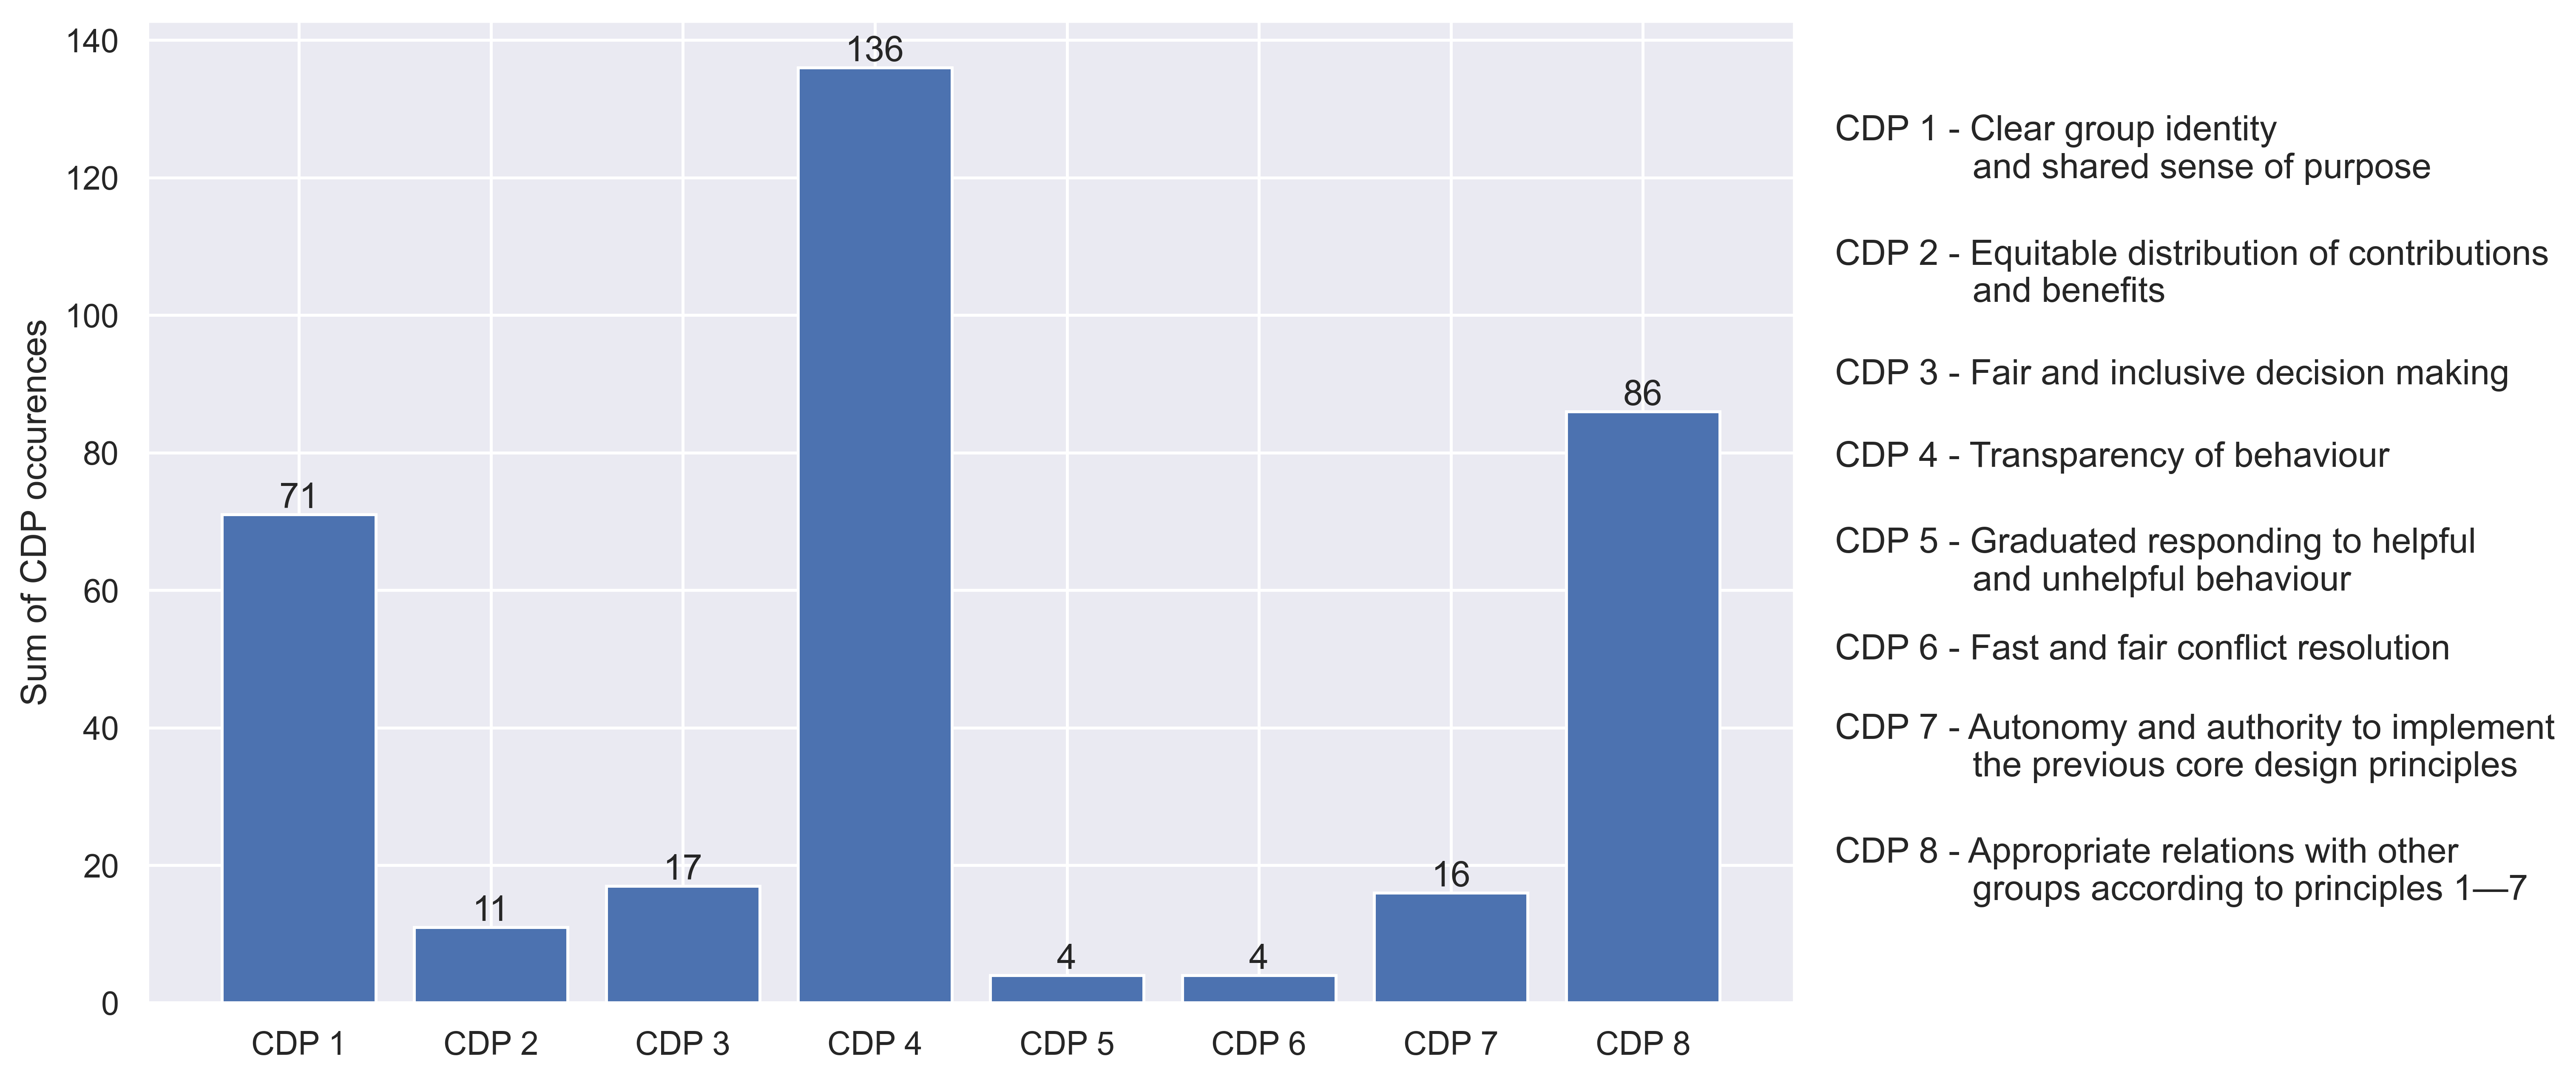

In [5]:
sns.set_theme(context='notebook')
plt.figure(figsize=(10,6), dpi =500)
bars = plt.bar(CDP_columns_sum.index, CDP_columns_sum.values, zorder=1)
plt.bar_label(bars)
plt.ylabel("Sum of CDP occurences")
plt.xticks([0,1,2,3,4,5,6,7], ["CDP 1", "CDP 2", "CDP 3", "CDP 4", "CDP 5", "CDP 6", "CDP 7", "CDP 8"])
plt.text(8, 120, "CDP 1 - Clear group identity\n              and shared sense of purpose")
plt.text(8, 102, "CDP 2 - Equitable distribution of contributions\n              and benefits")
plt.text(8, 90, "CDP 3 - Fair and inclusive decision making")
plt.text(8, 78, "CDP 4 - Transparency of behaviour")
plt.text(8, 60, "CDP 5 - Graduated responding to helpful\n              and unhelpful behaviour")
plt.text(8, 50, "CDP 6 - Fast and fair conflict resolution")
plt.text(8, 33, "CDP 7 - Autonomy and authority to implement\n              the previous core design principles ")
plt.text(8, 15, "CDP 8 - Appropriate relations with other\n              groups according to principles 1—7")
#plt.savefig("CDP_sum_bar.png", bbox_inches='tight')
plt.show()

### Mean of each CDP and total CDP

In [6]:
CDP_columns.mean()

CDP 1    0.452229
CDP 2    0.070064
CDP 3    0.108280
CDP 4    0.866242
CDP 5    0.025478
CDP 6    0.025478
CDP 7    0.101911
CDP 8    0.547771
dtype: float64

In [7]:
dataset['CDP Total'].mean()

2.1974522292993632

### Correlation of each CDP

As the CDPs are binary data, Spearman correlation will be used instead of Pearson.

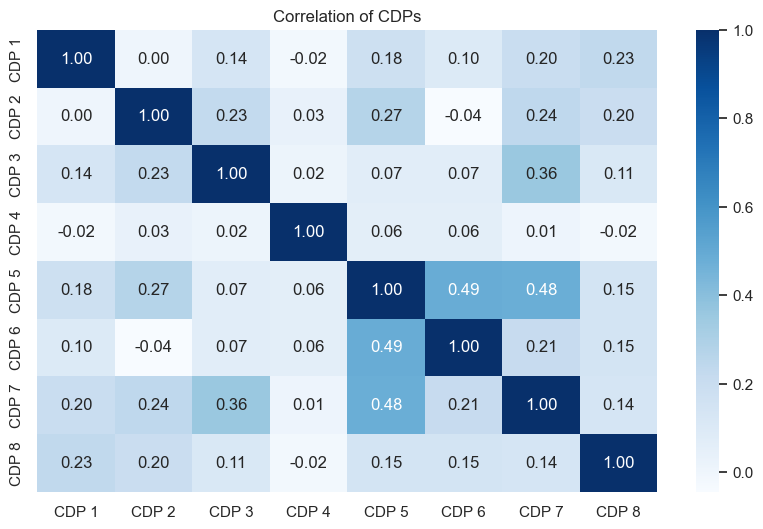

In [8]:
CDP_corr = CDP_columns.corr(method='spearman')
plt.figure(figsize =((10,6)))
sns.heatmap(CDP_corr, annot=True, cmap = "Blues", fmt='.2f')
plt.title('Correlation of CDPs')
plt.show()

### Count of Total CDPs

In [9]:
CDP_total_counts = dataset['CDP Total'].value_counts().sort_index()
CDP_total_counts = CDP_total_counts.reindex(range(9), fill_value=0)

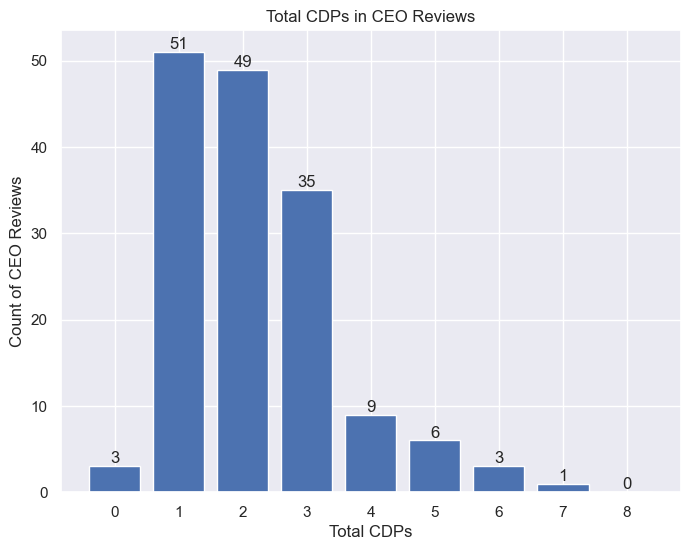

In [10]:
plt.figure(figsize=(8,6))
bars = plt.bar(CDP_total_counts.index, CDP_total_counts.values)
plt.bar_label(bars)
plt.title("Total CDPs in CEO Reviews")
plt.ylabel("Count of CEO Reviews")
plt.xlabel("Total CDPs")
plt.xticks(range(9))
#plt.savefig("CDP_total_counts.png", bbox_inches='tight')
plt.show()

### Without transparency

In [11]:
dataset[(dataset['CDP Total'] == 1) & (dataset['CDP 4'] == 0)].shape[0]

11

There are only 11 companies with CDP total = 1 if CDP 4 is not considered.

## CDP Clusters

CDPs can be clustered:
- Cluster 1 (CDP 1): Shared purpose
- Cluster 2 (CDP 2-6): Self-regulation
- Cluster 3 (CDP 7): Self-governance
- Cluster 4 (CDP 8): Multi-level

In [12]:
cluster_df = CDP_columns.copy()
cluster_df['Shared purpose'] = cluster_df['CDP 1']
cluster_df['Self-regulation'] = cluster_df[['CDP 2', 'CDP 3', 'CDP 4', 'CDP 5', 'CDP 6']].sum(axis=1)
cluster_df['Self-governance'] = cluster_df['CDP 7']
cluster_df['Multi-level'] = cluster_df['CDP 8']

In [13]:
cluster_df.head()

,CDP 1,CDP 2,CDP 3,CDP 4,CDP 5,CDP 6,CDP 7,CDP 8,Shared purpose,Self-regulation,Self-governance,Multi-level
0,1,0,0,1,0,0,0,1,1,1,0,1
1,0,1,1,1,0,0,0,1,0,3,0,1
2,0,0,0,1,0,0,0,0,0,1,0,0
3,1,0,0,0,0,0,0,1,1,0,0,1
4,1,0,0,1,0,0,0,1,1,1,0,1


### Self-regulation cluster

Count for CDPs inside the self regulation cluster.

In [14]:
self_reg_counts = [cluster_df[cluster_df['Self-regulation'] == 0].shape[0],
                   cluster_df[cluster_df['Self-regulation'] == 1].shape[0],
                   cluster_df[cluster_df['Self-regulation'] == 2].shape[0],
                   cluster_df[cluster_df['Self-regulation'] == 3].shape[0],
                   cluster_df[cluster_df['Self-regulation'] == 4].shape[0],
                   cluster_df[cluster_df['Self-regulation'] == 5].shape[0]]

cluster_graph_data = pd.DataFrame(self_reg_counts)
cluster_graph_data.index = ['0', '1', '2', '3', '4', '5']
print(cluster_graph_data)
cluster_df[(cluster_df['Self-regulation'] == 1) & (cluster_df['CDP 4'] == 1)].shape[0]

     0
0   18
1  115
2   16
3    7
4    1
5    0


112

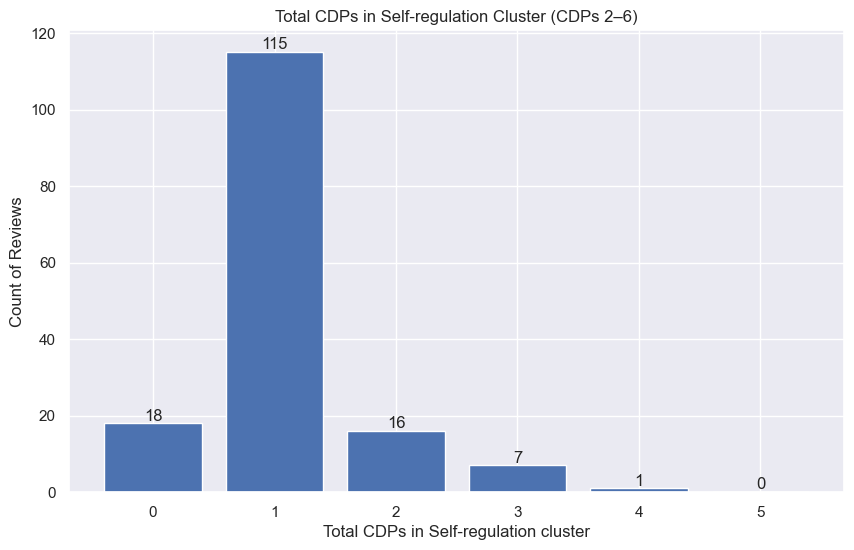

In [15]:
plt.figure(figsize=(10,6))
bars = plt.bar(cluster_graph_data.index, cluster_graph_data[0])
plt.title("Total CDPs in Self-regulation Cluster (CDPs 2–6)")
plt.ylabel("Count of Reviews")
plt.xlabel("Total CDPs in Self-regulation cluster")
plt.bar_label(bars)
#plt.savefig("CDP_self_reg_cluster", bbox_inches='tight')
plt.show()

## Correlation between clusters

In [16]:
cluster_corr = cluster_df[['Shared purpose','Self-regulation','Self-governance','Multi-level']].corr(method='spearman')
cluster_corr

,Shared purpose,Self-regulation,Self-governance,Multi-level
Shared purpose,1.000000,0.088626,0.201536,0.234196
Self-regulation,0.088626,1.000000,0.392595,0.151645
Self-governance,0.201536,0.392595,1.000000,0.136872
Multi-level,0.234196,0.151645,0.136872,1.000000


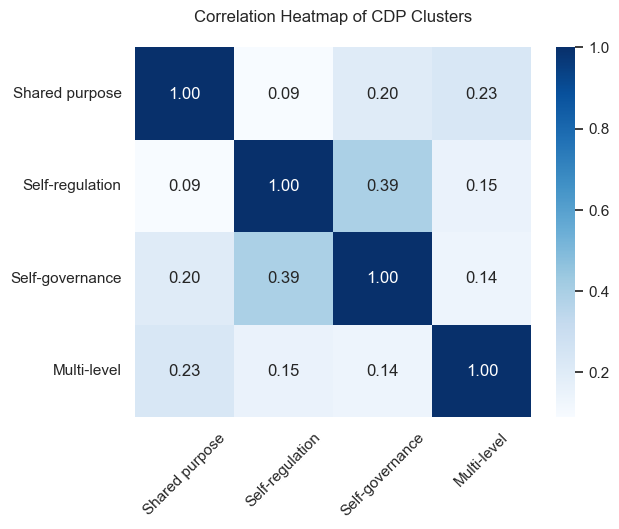

In [17]:
sns.heatmap(cluster_corr, annot=True, cmap='Blues', fmt=".2f")
plt.title('Correlation Heatmap of CDP Clusters\n')
plt.xticks(rotation=45)
#plt.savefig("CDP_cluster_correlations", bbox_inches='tight')
plt.show()

## 5.2 Sentiment patterns

In [18]:
sentiment_cols = ['Negative', 'Positive', 'Uncertainty', 'Litigious',
                  'Strong_Modal', 'Weak_Modal', 'Constraining', 'Word_Count']
dataset[sentiment_cols].describe()

,Negative,Positive,Uncertainty,Litigious,Strong_Modal,Weak_Modal,Constraining,Word_Count
count,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000,157.000000
mean,0.009418,0.036466,0.004961,0.001212,0.006413,0.001428,0.002362,780.496815
std,0.006466,0.012080,0.004066,0.001773,0.004124,0.001565,0.002148,361.552681
min,0.000000,0.013491,0.000000,0.000000,0.000000,0.000000,0.000000,114.000000
25%,0.004425,0.027834,0.002481,0.000000,0.003236,0.000000,0.000000,524.000000
50%,0.008685,0.035294,0.004073,0.000000,0.005566,0.001183,0.001933,710.000000
75%,0.012531,0.043415,0.006673,0.001855,0.009063,0.002237,0.003699,948.000000
max,0.040302,0.077381,0.028668,0.011236,0.019157,0.007634,0.007353,2317.000000


## Boxplot of Sentiment Measures

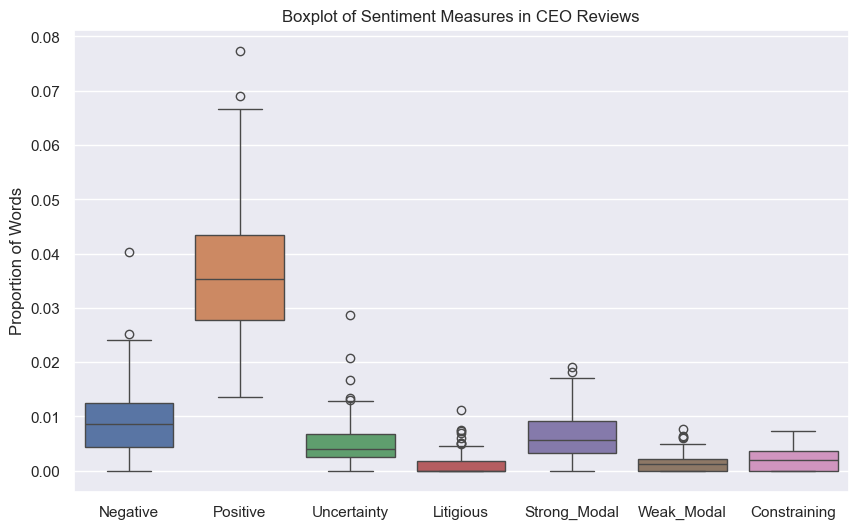

In [19]:
plt.figure(figsize=(10,6))
sns.boxplot(data=dataset[sentiment_cols].drop('Word_Count', axis=1))
plt.ylabel("Proportion of Words")
plt.title("Boxplot of Sentiment Measures in CEO Reviews")
#plt.savefig("Sentiment boxplot", bbox_inches='tight')
plt.show()

### Sentiment correlations with CDPs

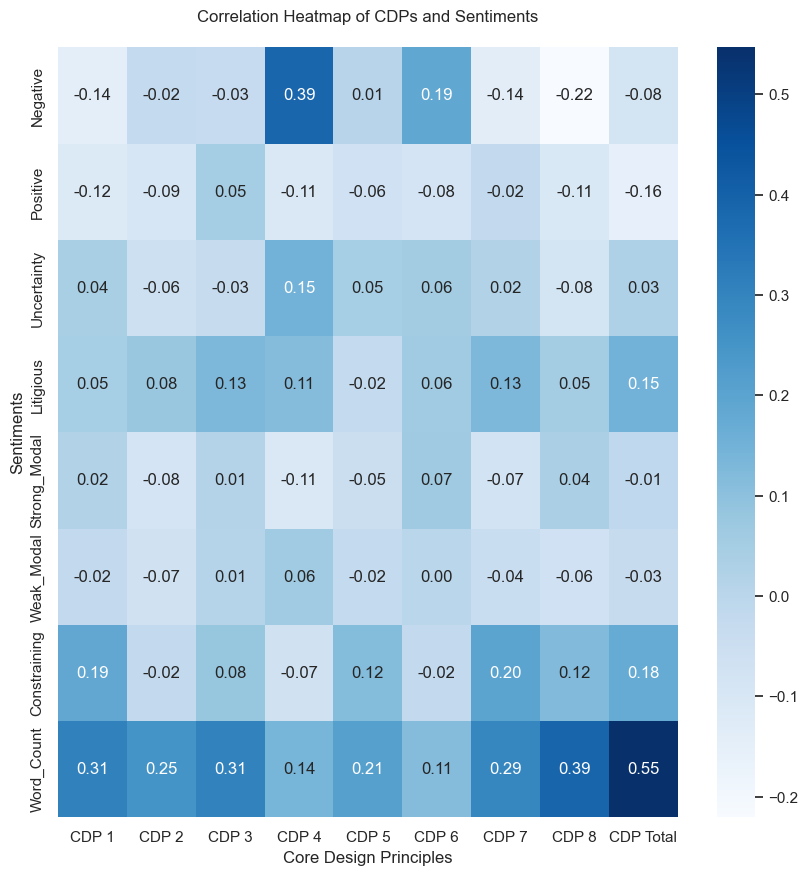

In [20]:
#sentiments are dataset[sentiment_cols]
cdps = dataset[['CDP 1','CDP 2','CDP 3','CDP 4','CDP 5','CDP 6','CDP 7','CDP 8', 'CDP Total']]
sentiments = dataset[sentiment_cols]

#only interested how sentiments correlate with cdp, not how everything correlates
cdp_sent_corr = cdps.apply(lambda x: sentiments.corrwith(x, method ='spearman'))
plt.figure(figsize=(10,10))
sns.heatmap(cdp_sent_corr, annot=True, cmap = "Blues", fmt=".2f")
plt.title('Correlation Heatmap of CDPs and Sentiments\n')
plt.ylabel('Sentiments')
plt.xlabel('Core Design Principles')
#plt.savefig("Sentiment and CDP correlations", bbox_inches='tight')
plt.show()


## Word Count's correlation with CDP Total

There is a strong correlation with CDP total and Word Count, but the question is is this just because more words = more space for CDPs?

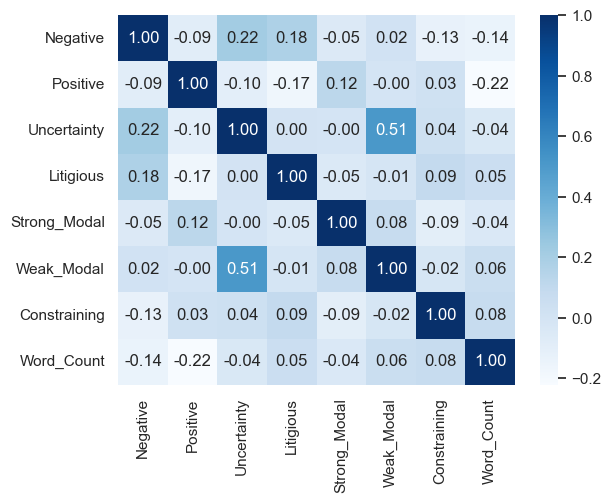

In [21]:
sns.heatmap(dataset[sentiment_cols].corr(), annot = True, cmap="Blues", fmt=".2f")
plt.show()

Word count does not correlate with any other sentiment. Here I used Pearson correlation, as this sentiment data is continuous.

### CDP Density

CDP density is constructed to check how oftern CDPs are discussed in relation to word count.

In [22]:
dataset['CDP_density'] = dataset['CDP Total'] / (dataset['Word_Count'])
print(dataset['CDP_density'].describe())
print('CV:', dataset['CDP_density'].std() / dataset['CDP_density'].mean())

count    157.000000
mean       0.003021
std        0.001658
min        0.000000
25%        0.001996
50%        0.002577
75%        0.003711
max        0.010274
Name: CDP_density, dtype: float64
CV: 0.5488391801959827


In [23]:
dataset[['CDP Total', 'Word_Count', 'CDP_density']].corr()

,CDP Total,Word_Count,CDP_density
CDP Total,1.000000,0.615161,0.497741
Word_Count,0.615161,1.000000,-0.269091
CDP_density,0.497741,-0.269091,1.000000


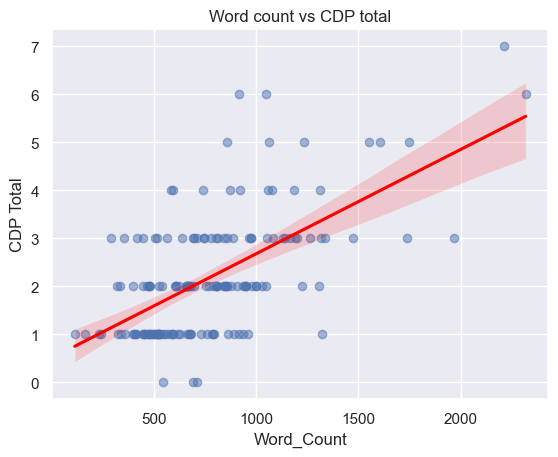

In [24]:
sns.regplot(data=dataset, x='Word_Count', y='CDP Total',
            scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title(f'Word count vs CDP total')
#plt.savefig("Word count vs CDP total", bbox_inches='tight')
plt.show()

## Core Design Principles In Different Segments and Sectors

### Segments

In [25]:
seg_stats = dataset.groupby('Segment').agg(
    n=('CDP Total', 'count'),
    mean_words = ('Word_Count', 'mean'),
    mean_cdp=('CDP Total', 'mean'),
    std_cdp=('CDP Total', 'std'),
    density=('CDP_density', 'mean')
).round(5)
print(seg_stats)

              n  mean_words  mean_cdp  std_cdp  density
Segment                                                
First North  35   637.11429   1.88571  0.96319  0.00310
Large Cap    30  1020.46667   2.76667  1.67504  0.00264
Mid Cap      47   808.91489   2.36170  1.35816  0.00324
Small Cap    45   702.35556   1.88889  0.93474  0.00299


### Statistical Tests

ANOVA can be used for data that is normally distributed, if the data is not normal then I will use Kruskal-Wallis.

In [26]:
#normality test to check if ANOVA or Kruskal-Wallis
for s in ['First North', 'Small Cap', 'Mid Cap', 'Large Cap']:
    data = dataset.loc[dataset['Segment']==s, 'CDP Total']
    W, p = stats.shapiro(data)
    print(f"  {s:<12} W = {W:.3f}, p = {p:.4f}")

  First North  W = 0.808, p = 0.0000
  Small Cap    W = 0.804, p = 0.0000
  Mid Cap      W = 0.901, p = 0.0008
  Large Cap    W = 0.932, p = 0.0559


p < 0.05 for First North, Small Cap, Mid Cap means that the data is not normally distributed.

In [27]:
groups = [dataset.loc[dataset['Segment']==s, 'CDP Total'] for s in ['First North', 'Small Cap', 'Mid Cap', 'Large Cap']]
H, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis: H = {H:.4f}, p = {p:.4f}")

Kruskal-Wallis: H = 8.6458, p = 0.0344


p is < 0.05, statistically significant so post hoc test

In [28]:
posthoc = sp.posthoc_dunn(dataset, val_col='CDP Total', 
                          group_col='Segment', p_adjust='bonferroni')
print(posthoc.round(3))

             First North  Large Cap  Mid Cap  Small Cap
First North        1.000      0.112    0.579      1.000
Large Cap          0.112      1.000    1.000      0.094
Mid Cap            0.579      1.000    1.000      0.530
Small Cap          1.000      0.094    0.530      1.000


None of the pairs are p < 0.05 so none are statistically significant. Because of this I'll conduct more descriptive and interpretive research based on the prevalences.

### Prevalence of each CDP by segment

Prevalences need to be percentages as groups are not same size.

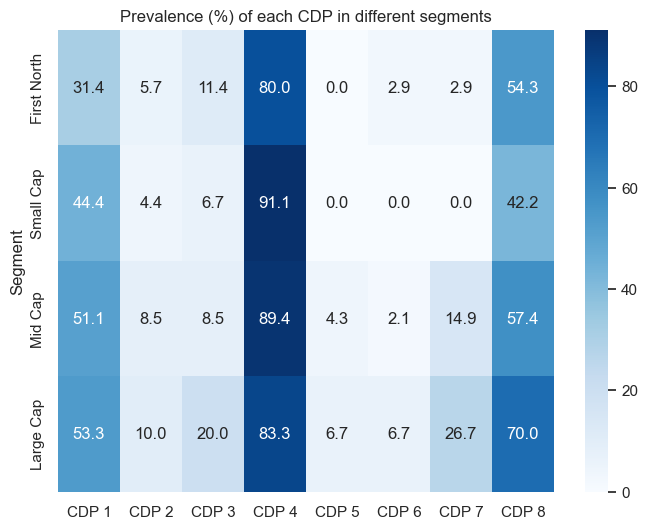

In [29]:
cdp_cols = ['CDP 1','CDP 2','CDP 3','CDP 4','CDP 5','CDP 6','CDP 7','CDP 8']
CDP_prevalence = dataset.groupby('Segment')[cdp_cols].mean()*100
#reindexing for clearer heatmap
CDP_prevalence = CDP_prevalence.reindex(['First North', 'Small Cap', 'Mid Cap', 'Large Cap'])

plt.figure(figsize=(8,6))
sns.heatmap(CDP_prevalence, annot = True, cmap = "Blues", fmt =".1f")
plt.title("Prevalence (%) of each CDP in different segments")
plt.show()

### Sentiments for segments

In [30]:
order = ['First North', 'Small Cap', 'Mid Cap', 'Large Cap']

seg_sent = dataset.groupby('Segment')[sentiment_cols].mean().reindex(order).round(4)
print(seg_sent)

             Negative  Positive  Uncertainty  Litigious  Strong_Modal  \
Segment                                                                 
First North    0.0085    0.0346       0.0053     0.0015        0.0062   
Small Cap      0.0121    0.0397       0.0054     0.0011        0.0069   
Mid Cap        0.0092    0.0337       0.0049     0.0011        0.0062   
Large Cap      0.0069    0.0381       0.0040     0.0012        0.0062   

             Weak_Modal  Constraining  Word_Count  
Segment                                            
First North      0.0017        0.0017    637.1143  
Small Cap        0.0012        0.0021    702.3556  
Mid Cap          0.0016        0.0027    808.9149  
Large Cap        0.0012        0.0031   1020.4667  


In [31]:
print(f"{'Sentiment':}{'H':>12}{'p':>10}")
for s in sentiment_cols:
    groups = [dataset.loc[dataset['Segment']==seg, s] for seg in order]
    H, p = stats.kruskal(*groups)
    print(f"{s:<16}{H:>8.3f}{p:>10.4f}")

Sentiment           H         p
Negative          12.765    0.0052
Positive           5.890    0.1171
Uncertainty        0.612    0.8937
Litigious          0.878    0.8308
Strong_Modal       1.671    0.6433
Weak_Modal         2.863    0.4132
Constraining       9.404    0.0244
Word_Count        22.652    0.0000


Negative and Constraining are statistically significant.

In [32]:
for s in ['Negative', 'Constraining']:
    print(f"\n=== Dunn's test (Bonferroni) — {s} ===")
    posthoc = sp.posthoc_dunn(dataset, val_col=s, group_col='Segment',
                              p_adjust='bonferroni')
    print(posthoc.round(3))


=== Dunn's test (Bonferroni) — Negative ===
             First North  Large Cap  Mid Cap  Small Cap
First North        1.000      1.000     1.00      0.099
Large Cap          1.000      1.000     0.66      0.004
Mid Cap            1.000      0.660     1.00      0.240
Small Cap          0.099      0.004     0.24      1.000

=== Dunn's test (Bonferroni) — Constraining ===
             First North  Large Cap  Mid Cap  Small Cap
First North        1.000      0.046    0.317      1.000
Large Cap          0.046      1.000    1.000      0.125
Mid Cap            0.317      1.000    1.000      0.797
Small Cap          1.000      0.125    0.797      1.000


For negative First North and Small Cap are statistically significant. <br> For constraining First North and Large Cap are relatively significant.

### Sectors

In [33]:
seg_stats = dataset.groupby('Sector').agg(
    n=('CDP Total', 'count'),
    mean_words = ('Word_Count', 'mean'),
    mean_cdp=('CDP Total', 'mean'),
    std_cdp=('CDP Total', 'std'),
    density=('CDP_density', 'mean')
).round(5)
print(seg_stats)

                         n  mean_words  mean_cdp  std_cdp  density
Sector                                                            
Basic Materials         11   771.81818   1.81818  0.87386  0.00294
Consumer Discretionary  23   751.82609   1.91304  1.23998  0.00275
Consumer Staples        10   838.10000   2.60000  1.34990  0.00329
Energy                   1   759.00000   1.00000      NaN  0.00132
Financials              15  1047.80000   2.80000  1.56753  0.00295
Health Care             13   767.23077   2.30769  1.25064  0.00308
Industrials             49   768.91837   2.10204  1.21183  0.00285
Real Estate              4   568.00000   1.50000  0.57735  0.00289
Technology              23   568.30435   2.04348  1.02151  0.00375
Telecommunications       5  1196.60000   3.80000  2.16795  0.00313
Utilities                3   974.00000   2.33333  1.15470  0.00232


### Statistical tests for sectors

For sectors I will also use Kruskal-Wallis, as there are huge differences in the n of companies in different groups, which breaks the ANOVA assumptions. I am also limiting for sectors with over 10 companies so the tests work as intended. Though I quickly tested with other values like 1 and 5 and there are no significant differences.

In [40]:
n_by_sector = dataset['Sector'].value_counts()
big_sectors = n_by_sector[n_by_sector >= 10].index.tolist()
df_big = dataset[dataset['Sector'].isin(big_sectors)]

groups = [df_big.loc[df_big['Sector']==s, 'CDP Total'] for s in big_sectors]
H, p = stats.kruskal(*groups)
print(f"CDP Total by sector (n≥10): H = {H:.3f}, p = {p:.4f}")

CDP Total by sector (n≥10): H = 6.302, p = 0.3903


p > 0.05 so no statistically significant.

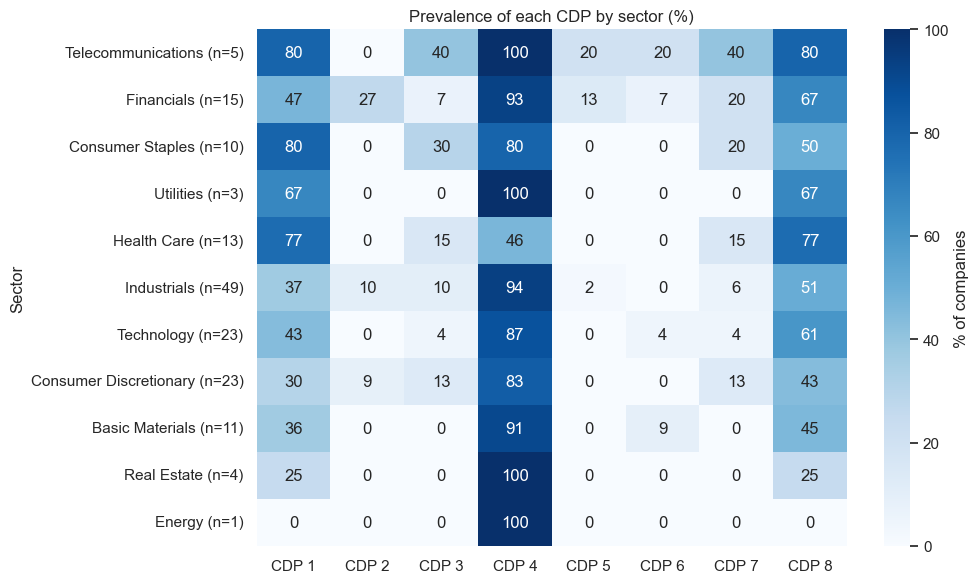

In [35]:
sector_cdp = (dataset.groupby('Sector')[cdp_cols].mean() * 100)
sector_cdp['mean_total'] = sector_cdp.sum(axis=1) / 100 
sector_cdp = sector_cdp.sort_values('mean_total', ascending=False).drop(columns='mean_total')

n_by_sector = dataset['Sector'].value_counts()
sector_cdp.index = [f"{s} (n={n_by_sector[s]})" for s in sector_cdp.index]

plt.figure(figsize=(10,6))
sns.heatmap(sector_cdp, annot=True, fmt='.0f', cmap='Blues',
            cbar_kws={'label': '% of companies'})
plt.title('Prevalence of each CDP by sector (%)')
plt.tight_layout()
plt.ylabel("Sector")
plt.savefig("Prevalence in different sectors.png")
plt.show()


In [36]:
sentiment_cols = ['Negative', 'Positive', 'Uncertainty', 'Litigious',
                  'Strong_Modal', 'Weak_Modal', 'Constraining']

seg_sent = dataset.groupby('Sector')[sentiment_cols].mean()
print(seg_sent)

                        Negative  Positive  Uncertainty  Litigious  \
Sector                                                               
Basic Materials         0.010052  0.034865     0.005339   0.001230   
Consumer Discretionary  0.007556  0.035927     0.003923   0.000654   
Consumer Staples        0.007042  0.038143     0.003532   0.000794   
Energy                  0.014493  0.031621     0.005270   0.001318   
Financials              0.009777  0.033363     0.006252   0.001299   
Health Care             0.006209  0.036151     0.006060   0.001835   
Industrials             0.011368  0.038181     0.005175   0.001308   
Real Estate             0.009393  0.025309     0.005145   0.002909   
Technology              0.009025  0.038454     0.004583   0.000963   
Telecommunications      0.006601  0.034586     0.004209   0.000896   
Utilities               0.015604  0.034142     0.005392   0.002265   

                        Strong_Modal  Weak_Modal  Constraining  
Sector                  

In [41]:
big_sectors = n_by_sector[n_by_sector >= 10].index.tolist()
df_big = dataset[dataset['Sector'].isin(big_sectors)]

groups = [df_big.loc[df_big['Sector']==s, 'CDP Total'] for s in big_sectors]
H, p = stats.kruskal(*groups)
print(f"CDP Total: H = {H:.2f}, p = {p:.4f}")

for s in sentiment_cols:
    groups = [df_big.loc[df_big['Sector']==sec, s] for sec in big_sectors]
    H, p = stats.kruskal(*groups)
    print(f"{s}: H = {H:.2f}, p = {p:.4f}")

CDP Total: H = 6.30, p = 0.3903
Negative: H = 12.45, p = 0.0526
Positive: H = 2.09, p = 0.9114
Uncertainty: H = 6.94, p = 0.3264
Litigious: H = 7.33, p = 0.2916
Strong_Modal: H = 6.66, p = 0.3532
Weak_Modal: H = 5.25, p = 0.5117
Constraining: H = 10.41, p = 0.1083


None of the sentiments are statistically significant, only negative is close.

## References and The Use of AI

Nasdaq: https://www.nasdaq.com/european-market-activity/shares <br>
Nordnet: https://www.nordnet.fi/osakkeet/kurssit?exchangeCountry=FI <br>

This work utilized AI-assisted tools (Claude Opus 4.7) as a support, especially in checking programming syntax and verifying details. The work's key ideas, methodological choises, and analysis are based on the author's own studies. For example, Kruskal-Wallis and post-hoc Dunn's test have been taught in statistics courses using R, so AI was used to efficiently find the corresponding Python syntax.